In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,Flatten,Dense

In [7]:
df = pd.read_csv("IMDB Dataset.csv")

X = df['review']
y = df['sentiment']

In [8]:
le = LabelEncoder()
y = le.fit_transform(y)

tok = Tokenizer(num_words=10000)
tok.fit_on_texts(X)

X = tok.texts_to_sequences(X)

X = pad_sequences(X,maxlen=200) #make all review of same length

In [9]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2
)

model = Sequential([
    Embedding(10000,32,input_length=200),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(1,activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [10]:
model.fit(X_train,y_train,epochs=5)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.8338 - loss: 0.3582
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.9556 - loss: 0.1229
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 21ms/step - accuracy: 0.9910 - loss: 0.0284
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - accuracy: 0.9966 - loss: 0.0104
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.9956 - loss: 0.0131


In [11]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8553 - loss: 0.8684
Test Loss: 0.8684117197990417
Test Accuracy: 0.8553000092506409


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


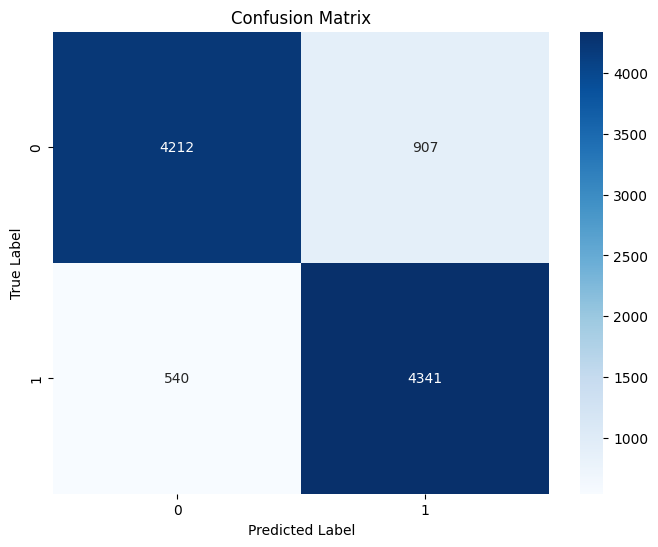

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.82      0.85      5119
           1       0.83      0.89      0.86      4881

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [14]:
# Calculate metrics
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
# Print classification report
print("Classification Report:\n", classification_rep)